## Chuẩn bị dữ liệu (train, test, val)

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Đọc dữ liệu
df = pd.read_csv('data_training.csv')

# Tách X, y
target_col = 'Depression'
X = df.drop(columns=[target_col])
y = df[target_col]

# Chia train/val/test = 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Số mẫu train: {len(X_train)}')
print(f'Số mẫu val  : {len(X_val)}')
print(f'Số mẫu test : {len(X_test)}')
print('\nTi lệ nhãn Depression trong train:')
print(y_train.value_counts(normalize=True).sort_index())

Số mẫu train: 98425
Số mẫu val  : 21091
Số mẫu test : 21092

Ti lệ nhãn Depression trong train:
Depression
0    0.81839
1    0.18161
Name: proportion, dtype: float64


## Random forest

### Giới thiệu model

Random Forest là mô hình học máy dạng ensemble, kết hợp nhiều Decision Tree để đưa ra dự đoán cuối cùng bằng cơ chế bỏ phiếu. Cách làm này giúp mô hình ổn định hơn một cây đơn lẻ, giảm nguy cơ overfitting và thường hoạt động tốt trên dữ liệu có nhiều loại đặc trưng khác nhau.

### Lý do chọn model
- Dữ liệu có cả biến số và biến phân loại nên Random Forest phù hợp vì học tốt trên dữ liệu hỗn hợp và bắt được quan hệ phi tuyến.
- Mô hình ít nhạy với nhiễu, không đòi hỏi giả định tuyến tính, và vẫn hoạt động tốt khi dữ liệu còn mất cân bằng lớp.
- Kết quả cũng dễ đánh giá bằng accuracy, precision, recall, F1 và confusion matrix trong phần kiểm thử.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Lấy danh sách cột số và cột categorical
num_cols = X_train.select_dtypes(include=['number']).columns
cat_cols = X_train.select_dtypes(exclude=['number']).columns

# OneHot encode cho cột categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough' 
)

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,           # số cây
        class_weight='balanced',    # xử lý mất cân bằng lớp
        random_state=42,            # cố định kết quả
        n_jobs=-1                   # dùng toàn bộ CPU để train nhanh hơn
    ))
])

### Train

In [18]:
# Train mô hình
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

### Đánh giá
#### Validation

Accuracy  : 0.9356
Precision : 0.8435
Recall    : 0.7922
F1-score  : 0.8170
                precision    recall  f1-score   support

Không trầm cảm       0.95      0.97      0.96     17261
      Trầm cảm       0.84      0.79      0.82      3830

      accuracy                           0.94     21091
     macro avg       0.90      0.88      0.89     21091
  weighted avg       0.93      0.94      0.93     21091



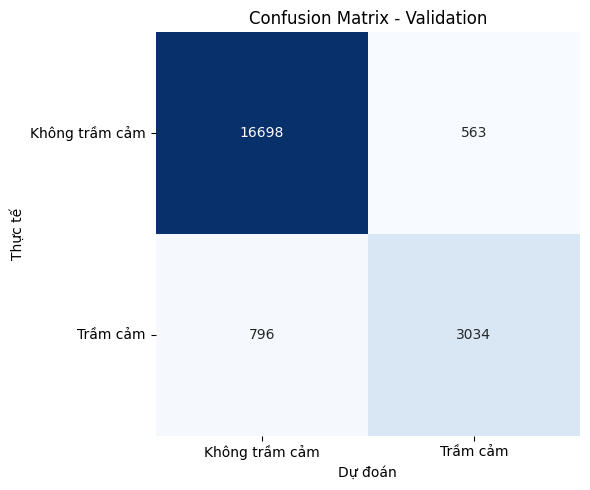

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Đánh giá trên tập validation
y_val_pred = rf_model.predict(X_val)
val_metrics = {
    'Accuracy': accuracy_score(y_val, y_val_pred),
    'Precision': precision_score(y_val, y_val_pred),
    'Recall': recall_score(y_val, y_val_pred),
    'F1-score': f1_score(y_val, y_val_pred)
}

# Classification report 
for name, val in val_metrics.items():
    print(f'{name:<10}: {val:.4f}')
print(classification_report(y_val, y_val_pred, target_names=['Không trầm cảm', 'Trầm cảm']))

# Confusion matrix
val_cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Validation')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.xticks([0.5, 1.5], ['Không trầm cảm', 'Trầm cảm'])
plt.yticks([0.5, 1.5], ['Không trầm cảm', 'Trầm cảm'], rotation=0)
plt.tight_layout()
plt.show()

#### Đánh giá trên tập test

Accuracy  : 0.9317
Precision : 0.8359
Recall    : 0.7763
F1-score  : 0.8050
                precision    recall  f1-score   support

Không trầm cảm       0.95      0.97      0.96     17261
      Trầm cảm       0.84      0.78      0.80      3831

      accuracy                           0.93     21092
     macro avg       0.89      0.87      0.88     21092
  weighted avg       0.93      0.93      0.93     21092



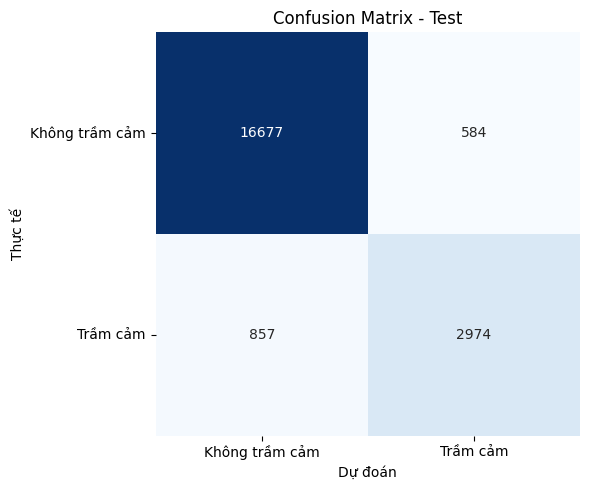

In [22]:
y_test_pred = rf_model.predict(X_test)
test_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1-score': f1_score(y_test, y_test_pred)
}

# Classification report 
for name, val in test_metrics.items():
    print(f'{name:<10}: {val:.4f}')
print(classification_report(y_test, y_test_pred, target_names=['Không trầm cảm', 'Trầm cảm']))

# Confusion matrix
test_cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.xticks([0.5, 1.5], ['Không trầm cảm', 'Trầm cảm'])
plt.yticks([0.5, 1.5], ['Không trầm cảm', 'Trầm cảm'], rotation=0)
plt.tight_layout()
plt.show()

#### Nhận xét
Mô hình Random Forest cho kết quả khá tốt trên cả validation và test, với accuracy khoảng 93% và F1-score khoảng 0.81 trên tập test. Điều này cho thấy mô hình tổng quát hóa ổn, vì chênh lệch giữa validation và test không lớn.

Tuy nhiên, recall của lớp 'Trầm cảm' vẫn thấp hơn lớp 'Không trầm cảm', nên mô hình còn bỏ sót một phần người có nguy cơ trầm cảm. 